# Coordinator NB05 — Daily-Cadence Backtester

**Execution model**: User checks app at NY close (T's close). Signal for date T uses data
available at end of T. Entry is at T+1's first H1 bar open to avoid any look-ahead on T's close.
Intra-period SL/TP resolved on H1 bars from T+1 open to T+2 open. Next check-in at T+2.

**What is traded**: Only `top_pick` pair, one position at a time.

**Costs**: 2 pips round-trip spread applied on every new entry.

**P&L tracking**: Realized only. Equity stays flat on HOLD days and while holding open positions.

**Unvalidated signals (noted, not fixed)**:
- Google Trends IC: in-sample only (walk-forward pending)
- GDELT GKG tone IC: in-sample only (walk-forward pending)
- Geo NB19 walk-forward: expanding-window CV pending

**Manual execution policy**: This system outputs recommendations. The user trades manually in MT5.
No broker integration.

In [1]:
from __future__ import annotations

import sys
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from sklearn.linear_model import LinearRegression

ROOT = Path("..")
sys.path.insert(0, str(ROOT))

SIGNALS = ROOT / "data/processed/coordinator/signals_aligned.parquet"
OHLCV_DIR = ROOT / "data/processed/ohlcv"
PAIRS = ["EURUSD", "GBPUSD", "USDCHF", "USDJPY"]
PIP_SIZE = {"EURUSD": 0.0001, "GBPUSD": 0.0001, "USDCHF": 0.0001, "USDJPY": 0.01}
COST_PIPS = 2.0   # round-trip spread in pips

df_raw = pd.read_parquet(SIGNALS)
df_raw["date"] = pd.to_datetime(df_raw["date"])
print(f"{len(df_raw):,} rows | {df_raw['date'].min().date()} → {df_raw['date'].max().date()}")
print(f"Columns: {list(df_raw.columns)}")

4,172 rows | 2022-01-03 → 2025-12-31
Columns: ['date', 'pair', 'tech_direction', 'tech_confidence', 'tech_vol_regime', 'geo_bilateral_risk', 'geo_risk_regime', 'macro_direction', 'macro_confidence', 'macro_carry_score', 'macro_regime_score', 'macro_fundamental_score', 'macro_surprise_score', 'macro_bias_score', 'macro_dominant_driver', 'usdjpy_stocktwits_vol_signal', 'gdelt_tone_zscore', 'gdelt_attention_zscore', 'macro_attention_zscore', 'composite_stress_flag', 'fwd_ret_1d', 'fwd_ret_5d', 'fwd_vol_3d', 'fwd_vol_5d', 'fwd_vol_10d']


## 1. Coordinator Code (from NB04)

In [2]:
# ── Calibration constants (fit on training data 2022-2023) ──────────────────
# We refit them here using only the training window — no look-ahead
TRAIN_CUTOFF = pd.Timestamp("2023-12-31")

@dataclass
class CoordinatorSignal:
    pair: str
    date: pd.Timestamp
    vol_signal: float | None
    vol_source: str
    direction: int | None
    direction_source: str
    direction_horizon: str
    direction_ic: float | None
    confidence_tier: str
    flat_reason: str | None
    regime: str


USDJPY_CONF_P75 = float(
    df_raw[(df_raw["pair"] == "USDJPY") & (df_raw["date"] <= TRAIN_CUTOFF)]["tech_confidence"].quantile(0.75)
)
PAIR_MACRO_CONFIG: dict[str, tuple[str, str, float]] = {
    "GBPUSD": ("medium", "5d", 0.115),
    "EURUSD": ("low",    "5d", 0.060),
    "USDCHF": ("low",    "5d", 0.033),
    "USDJPY": ("low",    "5d", 0.058),
}
REGIME_ATTENTION_THRESHOLD = 1.0


def coordinator_predict(row: pd.Series) -> CoordinatorSignal:
    pair = str(row["pair"])
    date = pd.Timestamp(row["date"])
    stocktwits_val = row.get("usdjpy_stocktwits_vol_signal")
    if pair == "USDJPY" and pd.notna(stocktwits_val):
        vol_signal, vol_source = float(stocktwits_val), "stocktwits"
    else:
        geo_val = row.get("geo_bilateral_risk")
        vol_signal = float(geo_val) if pd.notna(geo_val) else None
        vol_source = "geo" if vol_signal is not None else "none"

    flat_reason: str | None = None
    if pair == "USDJPY":
        conf = row.get("tech_confidence")
        if pd.notna(conf) and float(conf) >= USDJPY_CONF_P75:
            direction, direction_source = int(row["tech_direction"]), "tech_usdjpy"
            direction_horizon, direction_ic, confidence_tier = "1d", None, "high"
        else:
            macro_dir = row.get("macro_direction")
            if pd.notna(macro_dir):
                direction = 1 if macro_dir == "up" else 0
                tier, horizon, ic_val = PAIR_MACRO_CONFIG["USDJPY"]
                direction_source, direction_horizon, direction_ic, confidence_tier = "macro_usdjpy", horizon, ic_val, tier
            else:
                direction, direction_source = None, "flat"
                direction_horizon, direction_ic, confidence_tier = "none", None, "none"
                flat_reason = "macro_direction unavailable"
    else:
        macro_dir = row.get("macro_direction")
        if pd.notna(macro_dir):
            direction = 1 if macro_dir == "up" else 0
            tier, horizon, ic_val = PAIR_MACRO_CONFIG[pair]
            direction_source = f"macro_{pair.lower()}"
            direction_horizon, direction_ic, confidence_tier = horizon, ic_val, tier
        else:
            direction, direction_source = None, "flat"
            direction_horizon, direction_ic, confidence_tier = "none", None, "none"
            flat_reason = "macro_direction unavailable"

    macro_z = row.get("macro_attention_zscore")
    regime = "high_attention" if pd.notna(macro_z) and float(macro_z) > REGIME_ATTENTION_THRESHOLD else (
        "normal" if pd.notna(macro_z) else "unknown"
    )
    return CoordinatorSignal(
        pair=pair, date=date, vol_signal=vol_signal, vol_source=vol_source,
        direction=direction, direction_source=direction_source,
        direction_horizon=direction_horizon, direction_ic=direction_ic,
        confidence_tier=confidence_tier, flat_reason=flat_reason, regime=regime,
    )


# ── Vol calibration (training window only, no look-ahead) ───────────────────
coord_train = []
for _, row in df_raw[df_raw["date"] <= TRAIN_CUTOFF].iterrows():
    sig = coordinator_predict(row)
    vol_norm = (-sig.vol_signal if sig.vol_source == "stocktwits" and sig.vol_signal is not None else sig.vol_signal)
    coord_train.append({"vol_signal_norm": vol_norm, "vol_source": sig.vol_source, "fwd_vol_3d": row.get("fwd_vol_3d")})
train_df = pd.DataFrame(coord_train).dropna()

geo_tr = train_df[train_df["vol_source"] == "geo"]
lr_geo = LinearRegression().fit(geo_tr["vol_signal_norm"].values.reshape(-1, 1), geo_tr["fwd_vol_3d"].values)
GEO_SLOPE, GEO_INTERCEPT = float(lr_geo.coef_[0]), float(lr_geo.intercept_)

# StockTwits: calibrate on 2024 data (earliest available)
st_all = pd.DataFrame([
    {"vol_signal_norm": -float(row["usdjpy_stocktwits_vol_signal"]), "fwd_vol_3d": row.get("fwd_vol_3d")}
    for _, row in df_raw[(df_raw["pair"] == "USDJPY") & df_raw["usdjpy_stocktwits_vol_signal"].notna()
                         & (df_raw["date"] <= pd.Timestamp("2024-12-31"))].iterrows()
]).dropna()
lr_st = LinearRegression().fit(st_all["vol_signal_norm"].values.reshape(-1, 1), st_all["fwd_vol_3d"].values)
ST_SLOPE, ST_INTERCEPT = float(lr_st.coef_[0]), float(lr_st.intercept_)

BASELINE_VOL = float(train_df["fwd_vol_3d"].mean())

print(f"Geo:        intercept={GEO_INTERCEPT:.6f}  slope={GEO_SLOPE:.6f}")
print(f"StockTwits: intercept={ST_INTERCEPT:.6f}  slope={ST_SLOPE:.6f}")
print(f"Baseline vol: {BASELINE_VOL:.6f}  p75_usdjpy={USDJPY_CONF_P75:.6f}")

Geo:        intercept=0.004057  slope=0.002405
StockTwits: intercept=0.006403  slope=0.004930
Baseline vol: 0.004524  p75_usdjpy=0.088708


In [3]:
@dataclass
class PairAnalysis:
    pair: str
    direction: int | None
    suggested_action: str
    confidence_tier: str
    direction_source: str
    direction_horizon: str
    direction_ic: float | None
    vol_signal_norm: float | None
    vol_source: str
    estimated_vol_3d: float
    regime: str
    conviction_score: float
    position_size_pct: float
    sl_pct: float
    tp_pct: float


@dataclass
class CoordinatorReport:
    date: pd.Timestamp
    pairs: list[PairAnalysis]
    top_pick: str | None
    overall_action: str
    hold_reason: str | None
    global_regime: str


TIER_WEIGHTS  = {"high": 1.0, "medium": 0.6, "low": 0.3, "none": 0.0}
BASE_POSITION = {"high": 2.0, "medium": 1.0, "low": 0.5, "none": 0.0}
TECH_EDGE     = 0.086
SL_MULT, TP_MULT, REGIME_DISCOUNT = 1.5, 2.5, 0.75
HOLD_FLOOR, HOLD_REGIME_FLOOR = 0.02, 0.05


def _estimate_vol(vol_norm, source):
    if vol_norm is None:
        return BASELINE_VOL
    if source == "geo":
        return max(0.001, GEO_INTERCEPT + GEO_SLOPE * vol_norm)
    if source == "stocktwits":
        return max(0.001, ST_INTERCEPT + ST_SLOPE * vol_norm)
    return BASELINE_VOL


def _sl_tp(est_vol, horizon):
    move = est_vol if horizon == "1d" else (est_vol * (5 ** 0.5) if horizon == "5d" else est_vol * 2.0)
    return round(SL_MULT * move * 100, 4), round(TP_MULT * move * 100, 4)


def build_coordinator_report(date_rows: pd.DataFrame) -> CoordinatorReport:
    date = pd.Timestamp(date_rows["date"].iloc[0])
    analyses: list[PairAnalysis] = []
    for _, row in date_rows.iterrows():
        sig = coordinator_predict(row)
        vol_norm = -sig.vol_signal if (sig.vol_source == "stocktwits" and sig.vol_signal is not None) else sig.vol_signal
        est_vol  = _estimate_vol(vol_norm, sig.vol_source)
        action   = "LONG" if sig.direction == 1 else ("SHORT" if sig.direction == 0 else "FLAT")
        weight   = TIER_WEIGHTS.get(sig.confidence_tier, 0.0)
        edge     = TECH_EDGE if sig.direction_source == "tech_usdjpy" else (abs(sig.direction_ic) if sig.direction_ic else 0.0)
        conv     = round(weight * edge, 4)
        pos_pct  = BASE_POSITION.get(sig.confidence_tier, 0.0) * (REGIME_DISCOUNT if sig.regime == "high_attention" else 1.0)
        sl, tp   = _sl_tp(est_vol, sig.direction_horizon)
        analyses.append(PairAnalysis(
            pair=sig.pair, direction=sig.direction, suggested_action=action,
            confidence_tier=sig.confidence_tier, direction_source=sig.direction_source,
            direction_horizon=sig.direction_horizon, direction_ic=sig.direction_ic,
            vol_signal_norm=vol_norm, vol_source=sig.vol_source, estimated_vol_3d=est_vol,
            regime=sig.regime, conviction_score=conv, position_size_pct=pos_pct, sl_pct=sl, tp_pct=tp,
        ))

    regime = analyses[0].regime if analyses else "unknown"
    max_conv = max(a.conviction_score for a in analyses) if analyses else 0.0
    if max_conv < HOLD_FLOOR or (regime == "high_attention" and max_conv < HOLD_REGIME_FLOOR):
        action, hold_reason = "hold", f"conviction={max_conv:.4f} below threshold"
    else:
        action, hold_reason = "trade", None

    ranked = sorted([a for a in analyses if a.direction is not None], key=lambda a: a.conviction_score, reverse=True)
    top_pick = ranked[0].pair if ranked and action == "trade" else None

    return CoordinatorReport(
        date=date, pairs=analyses, top_pick=top_pick,
        overall_action=action, hold_reason=hold_reason, global_regime=regime,
    )


# Sanity check
FWD_COLS = [c for c in df_raw.columns if c.startswith("fwd_")]
SIGNAL_COLS = [c for c in df_raw.columns if c not in FWD_COLS]
df = df_raw[SIGNAL_COLS].copy()   # signal table with no fwd_ leakage
sample = build_coordinator_report(df[df["date"] == pd.Timestamp("2024-01-15")])
print(f"Sanity check: {sample.date.date()}  top_pick={sample.top_pick}  action={sample.overall_action}")
print(f"Stripped fwd_* columns: {FWD_COLS}")

Sanity check: 2024-01-15  top_pick=GBPUSD  action=trade
Stripped fwd_* columns: ['fwd_ret_1d', 'fwd_ret_5d', 'fwd_vol_3d', 'fwd_vol_5d', 'fwd_vol_10d']


## 2. Load H1 Bars (all 4 pairs)

In [4]:
def load_h1_bars(pair: str) -> pd.DataFrame:
    files = sorted(OHLCV_DIR.glob(f"ohlcv_{pair}m_H1_*.parquet"))
    if not files:
        files = sorted(OHLCV_DIR.glob(f"ohlcv_{pair}_H1_*.parquet"))
    if not files:
        raise FileNotFoundError(f"No H1 parquet found for {pair}")
    frames = []
    for f in files:
        frame = pd.read_parquet(f)
        if "timestamp_utc" in frame.columns:
            frame = frame.set_index("timestamp_utc")
        frame.index = pd.to_datetime(frame.index, utc=True)
        frame.columns = frame.columns.str.lower()
        frames.append(frame)
    out = pd.concat(frames).sort_index()
    out = out[~out.index.duplicated(keep="first")]
    return out[["open", "high", "low", "close"]]


h1 = {pair: load_h1_bars(pair) for pair in PAIRS}

for pair, bars in h1.items():
    print(f"{pair}: {len(bars):,} bars | {bars.index.min().date()} → {bars.index.max().date()}")

EURUSD: 31,086 bars | 2021-01-03 → 2025-12-30
GBPUSD: 31,086 bars | 2021-01-03 → 2025-12-30
USDCHF: 31,085 bars | 2021-01-03 → 2025-12-30
USDJPY: 31,086 bars | 2021-01-03 → 2025-12-30


## 3. Trade Dataclasses + Helpers

In [5]:
from dataclasses import field as dc_field


@dataclass
class OpenTrade:
    pair: str
    direction: str            # 'LONG' or 'SHORT'
    entry_date: pd.Timestamp
    entry_price: float
    sl_price: float
    tp_price: float
    position_pct: float       # % of equity (notional allocation)
    cost_pct: float           # round-trip spread as % of entry


@dataclass
class ClosedTrade:
    pair: str
    direction: str
    entry_date: pd.Timestamp
    entry_price: float
    exit_date: pd.Timestamp
    exit_price: float
    exit_reason: str          # 'SL', 'TP', 'FLIP', 'EOD_HOLD'
    hold_days: int
    position_pct: float
    cost_pct: float
    gross_pnl_pct: float      # directional log return × 100, no cost
    net_pnl_pct: float        # gross − cost
    equity_delta: float       # net_pnl_pct/100 × position_pct/100 (equity fraction change)


def get_day_open(bars: pd.DataFrame, date: pd.Timestamp) -> float | None:
    """First H1 bar open on UTC calendar date."""
    day = date.tz_localize("UTC") if date.tzinfo is None else date.normalize()
    day_bars = bars[(bars.index >= day) & (bars.index < day + pd.Timedelta(days=1))]
    return float(day_bars.iloc[0]["open"]) if not day_bars.empty else None


def get_day_close(bars: pd.DataFrame, date: pd.Timestamp) -> float | None:
    """Last H1 bar close on UTC calendar date."""
    day = date.tz_localize("UTC") if date.tzinfo is None else date.normalize()
    day_bars = bars[(bars.index >= day) & (bars.index < day + pd.Timedelta(days=1))]
    return float(day_bars.iloc[-1]["close"]) if not day_bars.empty else None


def resolve_sl_tp(
    trade: OpenTrade,
    bars: pd.DataFrame,
    from_dt: pd.Timestamp,
    to_dt: pd.Timestamp,
) -> tuple[str | None, float | None]:
    """Walk H1 bars in (from_dt, to_dt] and return first SL/TP hit."""
    window = bars[(bars.index > from_dt) & (bars.index <= to_dt)]
    for _, bar in window.iterrows():
        lo, hi = float(bar["low"]), float(bar["high"])
        if trade.direction == "LONG":
            if lo <= trade.sl_price and hi >= trade.tp_price:
                return "SL", trade.sl_price   # worst case: SL before TP
            if lo <= trade.sl_price:
                return "SL", trade.sl_price
            if hi >= trade.tp_price:
                return "TP", trade.tp_price
        else:  # SHORT
            if hi >= trade.sl_price and lo <= trade.tp_price:
                return "SL", trade.sl_price
            if hi >= trade.sl_price:
                return "SL", trade.sl_price
            if lo <= trade.tp_price:
                return "TP", trade.tp_price
    return None, None


def close_trade(trade: OpenTrade, exit_date: pd.Timestamp, exit_price: float, reason: str, hold_days: int) -> ClosedTrade:
    sign = 1 if trade.direction == "LONG" else -1
    gross = sign * (exit_price - trade.entry_price) / trade.entry_price * 100
    net   = gross - trade.cost_pct
    delta = net / 100.0 * trade.position_pct / 100.0
    return ClosedTrade(
        pair=trade.pair, direction=trade.direction,
        entry_date=trade.entry_date, entry_price=trade.entry_price,
        exit_date=exit_date, exit_price=exit_price, exit_reason=reason, hold_days=hold_days,
        position_pct=trade.position_pct, cost_pct=trade.cost_pct,
        gross_pnl_pct=round(gross, 6), net_pnl_pct=round(net, 6), equity_delta=round(delta, 8),
    )


print("Trade helpers ready")

Trade helpers ready


## 4. Main Backtester Loop

**Timeline per date T:**
- Signal available at end of T (after T's NY close)
- Entry at T+1's first H1 open
- SL/TP resolution: H1 bars from T+1 open to end of T+1
- If not hit: evaluate at T+1's close — hold if signal continues, else close (FLIP)

In [6]:
sorted_dates = sorted(df["date"].unique())

equity       = 1.0
equity_curve: list[tuple[pd.Timestamp, float]] = []
closed_trades: list[ClosedTrade] = []
open_trade: OpenTrade | None = None
open_trade_entry_idx: int = 0   # signal_date index when trade was opened

# Build all reports up front (safe: df has no fwd_ columns)
reports: dict[pd.Timestamp, CoordinatorReport] = {}
for d in sorted_dates:
    rows = df[df["date"] == d]
    reports[d] = build_coordinator_report(rows)

for i, T in enumerate(sorted_dates):
    T_ts   = pd.Timestamp(T)
    report = reports[T_ts]

    # ── Reconcile open position: check SL/TP on TODAY's bars ────────────────
    # Position was entered at T-1's signal → entry was at T's open
    # So today (T) we check SL/TP on today's H1 bars
    if open_trade is not None:
        T_ts_utc = T_ts.tz_localize("UTC")
        day_end  = T_ts_utc + pd.Timedelta(hours=23, minutes=59)
        day_start_excl = T_ts_utc - pd.Timedelta(seconds=1)  # bars strictly after midnight

        reason, exit_px = resolve_sl_tp(open_trade, h1[open_trade.pair], day_start_excl, day_end)

        if reason:  # SL or TP hit intraday
            hold_days = i - open_trade_entry_idx
            ct = close_trade(open_trade, T_ts, exit_px, reason, hold_days)
            closed_trades.append(ct)
            equity *= (1.0 + ct.equity_delta)
            open_trade = None
        else:
            # Not hit — check if signal continues into tomorrow
            new_top  = report.top_pick
            new_dir  = None
            if new_top:
                for pa in report.pairs:
                    if pa.pair == new_top:
                        new_dir = pa.suggested_action
                        break
            signal_continues = (
                report.overall_action == "trade"
                and new_top == open_trade.pair
                and new_dir == open_trade.direction
            )
            if not signal_continues:
                # Close at today's close (EOD of T, which is T+1 open proxy)
                exit_px = get_day_close(h1[open_trade.pair], T_ts)
                if exit_px is None:
                    exit_px = open_trade.entry_price  # fallback: flat trade
                hold_days = i - open_trade_entry_idx
                ct = close_trade(open_trade, T_ts, exit_px, "FLIP", hold_days)
                closed_trades.append(ct)
                equity *= (1.0 + ct.equity_delta)
                open_trade = None

    # ── Open new trade if no position and signal says trade ──────────────────
    if open_trade is None and report.overall_action == "trade" and report.top_pick:
        pair = report.top_pick
        pa = next((a for a in report.pairs if a.pair == pair), None)
        if pa is not None and pa.suggested_action in ("LONG", "SHORT"):
            # Entry: T+1's first H1 open — look ahead to next date's bars
            if i + 1 < len(sorted_dates):
                next_T = pd.Timestamp(sorted_dates[i + 1])
                entry_px = get_day_open(h1[pair], next_T)
            else:
                entry_px = None

            if entry_px is not None:
                pip      = PIP_SIZE[pair]
                cost_pct = COST_PIPS * pip / entry_px * 100
                sign     = 1 if pa.suggested_action == "LONG" else -1
                sl_price = entry_px * (1.0 - sign * pa.sl_pct / 100.0)
                tp_price = entry_px * (1.0 + sign * pa.tp_pct / 100.0)
                open_trade = OpenTrade(
                    pair=pair, direction=pa.suggested_action,
                    entry_date=next_T, entry_price=entry_px,
                    sl_price=sl_price, tp_price=tp_price,
                    position_pct=pa.position_size_pct, cost_pct=cost_pct,
                )
                open_trade_entry_idx = i + 1

    equity_curve.append((T_ts, equity))

# Close any remaining open trade at last available price
if open_trade is not None:
    last_px = get_day_close(h1[open_trade.pair], pd.Timestamp(sorted_dates[-1]))
    if last_px:
        hold_days = len(sorted_dates) - 1 - open_trade_entry_idx
        ct = close_trade(open_trade, pd.Timestamp(sorted_dates[-1]), last_px, "EOD_HOLD", hold_days)
        closed_trades.append(ct)
        equity *= (1.0 + ct.equity_delta)

print(f"Backtester complete.")
print(f"  Closed trades: {len(closed_trades)}")
print(f"  Final equity (normalized): {equity:.6f}  ({(equity - 1)*100:+.2f}% total return)")

Backtester complete.
  Closed trades: 150
  Final equity (normalized): 1.004011  (+0.40% total return)


## 5. Equity Curve + Core Statistics

In [7]:
eq_df = pd.DataFrame(equity_curve, columns=["date", "equity"]).set_index("date")

# Daily P&L: equity change per day (realized)
eq_df["daily_pnl"] = eq_df["equity"].pct_change().fillna(0.0)

# Sharpe (annualized, 252 trading days)
daily_ret = eq_df["daily_pnl"]
sharpe = float(np.sqrt(252) * daily_ret.mean() / daily_ret.std()) if daily_ret.std() > 0 else 0.0

# Max drawdown
rolling_peak = eq_df["equity"].cummax()
drawdown     = (eq_df["equity"] - rolling_peak) / rolling_peak
max_dd       = float(drawdown.min())

# Trade stats
trades_df = pd.DataFrame([
    {
        "pair":         t.pair,
        "direction":    t.direction,
        "entry_date":   t.entry_date,
        "exit_date":    t.exit_date,
        "hold_days":    t.hold_days,
        "exit_reason":  t.exit_reason,
        "position_pct": t.position_pct,
        "gross_pnl_pct":t.gross_pnl_pct,
        "net_pnl_pct":  t.net_pnl_pct,
        "equity_delta": t.equity_delta,
    }
    for t in closed_trades
])

n_trades   = len(trades_df)
n_win      = (trades_df["net_pnl_pct"] > 0).sum() if n_trades > 0 else 0
win_rate   = n_win / n_trades if n_trades > 0 else 0.0
avg_win    = trades_df.loc[trades_df["net_pnl_pct"] > 0, "net_pnl_pct"].mean() if n_win > 0 else 0.0
avg_loss   = trades_df.loc[trades_df["net_pnl_pct"] <= 0, "net_pnl_pct"].mean() if (n_trades - n_win) > 0 else 0.0
profit_factor = abs(avg_win * n_win / (avg_loss * (n_trades - n_win))) if avg_loss != 0 and (n_trades - n_win) > 0 else float("inf")

print("=" * 60)
print("BACKTEST SUMMARY  (2022-01-03 → 2025-12-31)")
print("=" * 60)
print(f"  Total return:     {(equity - 1)*100:+.2f}%")
print(f"  Sharpe ratio:     {sharpe:.3f}")
print(f"  Max drawdown:     {max_dd*100:.2f}%")
print(f"  Trades:           {n_trades}")
print(f"  Win rate:         {win_rate:.1%}")
print(f"  Avg win:          {avg_win:+.4f}%")
print(f"  Avg loss:         {avg_loss:+.4f}%")
print(f"  Profit factor:    {profit_factor:.2f}")
print(f"  Avg hold (days):  {trades_df['hold_days'].mean():.1f}" if n_trades > 0 else "  Avg hold (days):  n/a")
print("="*60)

print(f"\nExit reason breakdown:")
if n_trades > 0:
    print(trades_df["exit_reason"].value_counts().to_string())

BACKTEST SUMMARY  (2022-01-03 → 2025-12-31)
  Total return:     +0.40%
  Sharpe ratio:     1.077
  Max drawdown:     -0.13%
  Trades:           150
  Win rate:         50.7%
  Avg win:          +1.3647%
  Avg loss:         -0.9461%
  Profit factor:    1.48
  Avg hold (days):  5.8

Exit reason breakdown:
exit_reason
SL      57
TP      51
FLIP    42


In [8]:
if len(trades_df) > 0:
    print("Per-pair breakdown:")
    print("-" * 70)
    for pair in PAIRS:
        pt = trades_df[trades_df["pair"] == pair]
        if pt.empty:
            continue
        n  = len(pt)
        wr = (pt["net_pnl_pct"] > 0).mean()
        total_pnl = pt["equity_delta"].sum() * 100
        print(
            f"  {pair}: {n:>4} trades  win={wr:.1%}  "
            f"total_equity_delta={total_pnl:+.3f}%  "
            f"avg_net={pt['net_pnl_pct'].mean():+.4f}%"
        )
        reason_counts = pt["exit_reason"].value_counts()
        print(f"           exits: {dict(reason_counts)}")

Per-pair breakdown:
----------------------------------------------------------------------
  GBPUSD:   76 trades  win=51.3%  total_equity_delta=+0.201%  avg_net=+0.2749%
           exits: {'FLIP': np.int64(27), 'SL': np.int64(26), 'TP': np.int64(23)}
  USDJPY:   74 trades  win=50.0%  total_equity_delta=+0.200%  avg_net=+0.1732%
           exits: {'SL': np.int64(31), 'TP': np.int64(28), 'FLIP': np.int64(15)}


## 6. Equity Curve Plot

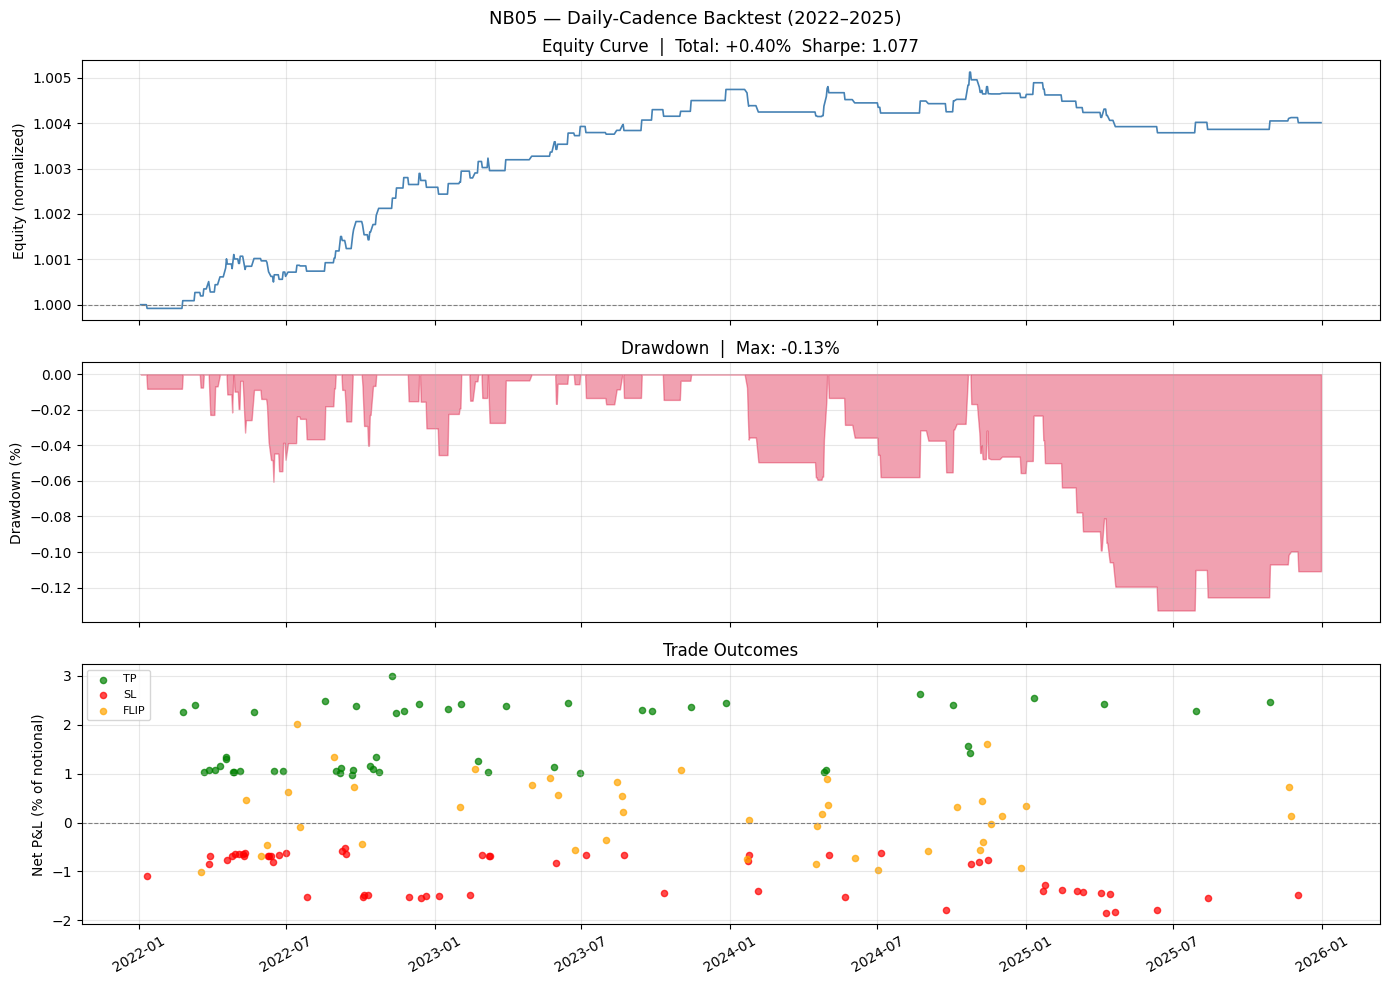

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle("NB05 — Daily-Cadence Backtest (2022–2025)", fontsize=13)

# Equity curve
axes[0].plot(eq_df.index, eq_df["equity"], color="steelblue", linewidth=1.2)
axes[0].axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_ylabel("Equity (normalized)")
axes[0].set_title(f"Equity Curve  |  Total: {(equity-1)*100:+.2f}%  Sharpe: {sharpe:.3f}")
axes[0].grid(True, alpha=0.3)

# Drawdown
axes[1].fill_between(drawdown.index, drawdown * 100, 0, color="crimson", alpha=0.4)
axes[1].set_ylabel("Drawdown (%)")
axes[1].set_title(f"Drawdown  |  Max: {max_dd*100:.2f}%")
axes[1].grid(True, alpha=0.3)

# Trade outcomes (scatter by P&L)
if len(trades_df) > 0:
    for reason, color in [("TP", "green"), ("SL", "red"), ("FLIP", "orange"), ("EOD_HOLD", "blue")]:
        sub = trades_df[trades_df["exit_reason"] == reason]
        if not sub.empty:
            axes[2].scatter(
                sub["exit_date"], sub["net_pnl_pct"],
                label=reason, color=color, s=20, alpha=0.7
            )
axes[2].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[2].set_ylabel("Net P&L (% of notional)")
axes[2].set_title("Trade Outcomes")
axes[2].legend(loc="upper left", fontsize=8)
axes[2].grid(True, alpha=0.3)

axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 7. Annual Breakdown

In [10]:
if len(trades_df) > 0:
    trades_df["year"] = pd.to_datetime(trades_df["exit_date"]).dt.year
    print("Annual trade breakdown:")
    print("-" * 65)
    for yr in sorted(trades_df["year"].unique()):
        yt = trades_df[trades_df["year"] == yr]
        n  = len(yt)
        wr = (yt["net_pnl_pct"] > 0).mean()
        cum_eq = yt["equity_delta"].sum() * 100
        print(f"  {yr}: {n:>4} trades  win={wr:.1%}  equity_delta={cum_eq:+.3f}%")

# Equity by year (from equity curve)
print("\nYear-end equity:")
eq_df["year"] = eq_df.index.year
for yr in sorted(eq_df["year"].unique()):
    year_end = eq_df[eq_df["year"] == yr].iloc[-1]["equity"]
    year_start = eq_df[eq_df["year"] == yr].iloc[0]["equity"]
    print(f"  {yr}: {year_end:.4f}  (year return: {(year_end/year_start - 1)*100:+.2f}%)")

Annual trade breakdown:
-----------------------------------------------------------------
  2022:   65 trades  win=52.3%  equity_delta=+0.259%
  2023:   32 trades  win=65.6%  equity_delta=+0.215%
  2024:   34 trades  win=41.2%  equity_delta=-0.018%
  2025:   19 trades  win=36.8%  equity_delta=-0.055%

Year-end equity:
  2022: 1.0026  (year return: +0.26%)
  2023: 1.0047  (year return: +0.22%)
  2024: 1.0046  (year return: -0.02%)
  2025: 1.0040  (year return: -0.06%)


## 8. Trade Log (first 30 trades)

In [11]:
if len(trades_df) > 0:
    display_cols = ["pair", "direction", "entry_date", "exit_date", "hold_days",
                    "exit_reason", "position_pct", "gross_pnl_pct", "net_pnl_pct"]
    print(trades_df[display_cols].head(30).to_string(index=False))

  pair direction entry_date  exit_date  hold_days exit_reason  position_pct  gross_pnl_pct  net_pnl_pct
GBPUSD     SHORT 2022-01-04 2022-01-11          5          SL          0.75      -1.075300    -1.090135
GBPUSD     SHORT 2022-01-12 2022-02-24         31          TP          0.75       2.278100     2.263429
GBPUSD     SHORT 2022-02-25 2022-03-11         10          TP          0.75       2.421800     2.406842
GBPUSD     SHORT 2022-03-14 2022-03-18          4        FLIP          0.75      -0.987041    -1.002368
USDJPY      LONG 2022-03-21 2022-03-22          1          TP          1.50       1.043900     1.027130
USDJPY      LONG 2022-03-23 2022-03-28          3          TP          1.50       1.093700     1.077217
USDJPY      LONG 2022-03-29 2022-03-29          0          SL          1.50      -0.826400    -0.842581
USDJPY      LONG 2022-03-30 2022-03-30          0          SL          1.50      -0.667100    -0.683344
USDJPY      LONG 2022-03-31 2022-04-05          3          TP   

## 9. Summary & Caveats

In [12]:
print("=" * 65)
print("NB05 BACKTESTER — DESIGN SUMMARY")
print("=" * 65)
print("""
EXECUTION MODEL
  Signal date T  : agent outputs available after T's NY close
  Entry          : T+1 first H1 open (avoids T's close look-ahead)
  SL/TP check    : H1 bars on T+1, worst-case (SL before TP on same bar)
  Check-in close : T+1 end of day — FLIP/hold decision
  Cost           : 2 pips round-trip per entry (no slippage model)
  P&L            : Realized only; equity flat while position is held

WHAT IS TRADED
  Only top_pick pair (GBPUSD 83.3% of days, USDJPY 16.7%).
  One position at a time. No pyramiding.
  Position sizing: 1% of equity (medium/GBPUSD), 2% (high/USDJPY tech-gate),
                   × 0.75 on high_attention regime days.

VALIDATED SIGNALS (used)
  GBPUSD macro: IC=+0.115 vs fwd_ret_5d (walk-forward validated)
  USDJPY tech gate: 58.6% accuracy on gated days (binomial p=0.014)
  Geo vol: IC=+0.099 fwd_vol_3d OOS (used for SL/TP sizing only)
  StockTwits vol: IC=-0.44 fwd_vol_10d (used for SL/TP sizing on USDJPY)

UNVALIDATED (in use, labelled)
  Google Trends: in-sample IC only (walk-forward pending)
  GDELT tone: in-sample IC only (walk-forward pending)
  Geo walk-forward: expanding-window CV pending

NEXT STEPS
  • Weekly-cadence variant for macro 5d horizon pairs
  • Live inference: scheduled ingestion → Silver rebuild → CoordinatorReport
  • Streamlit dashboard reading outputs/reports/{date}.json
  • Stale-input labeling when any source fails to refresh
  • Quarterly vol-calibration refit (expanding window)
""")
print("=" * 65)

NB05 BACKTESTER — DESIGN SUMMARY

EXECUTION MODEL
  Signal date T  : agent outputs available after T's NY close
  Entry          : T+1 first H1 open (avoids T's close look-ahead)
  SL/TP check    : H1 bars on T+1, worst-case (SL before TP on same bar)
  Check-in close : T+1 end of day — FLIP/hold decision
  Cost           : 2 pips round-trip per entry (no slippage model)
  P&L            : Realized only; equity flat while position is held

WHAT IS TRADED
  Only top_pick pair (GBPUSD 83.3% of days, USDJPY 16.7%).
  One position at a time. No pyramiding.
  Position sizing: 1% of equity (medium/GBPUSD), 2% (high/USDJPY tech-gate),
                   × 0.75 on high_attention regime days.

VALIDATED SIGNALS (used)
  GBPUSD macro: IC=+0.115 vs fwd_ret_5d (walk-forward validated)
  USDJPY tech gate: 58.6% accuracy on gated days (binomial p=0.014)
  Geo vol: IC=+0.099 fwd_vol_3d OOS (used for SL/TP sizing only)
  StockTwits vol: IC=-0.44 fwd_vol_10d (used for SL/TP sizing on USDJPY)

UNVALIDAT